# Logistic Regression - Crop Recommendation System

**Algorithm:** Multinomial Logistic Regression  
**Type:** Linear Classification (Baseline Model)  
**Use Case:** Multi-class classification for 22 crop types


In [1]:
%pip install scikit-learn numpy pandas matplotlib seaborn joblib

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)

In [9]:
#load dataset
data_url = "https://raw.githubusercontent.com/dphi-official/Datasets/master/crop_recommendation/train_set_label.csv"
df = pd.read_csv(data_url)

print(df.head()) 

       N      P      K  temperature   humidity        ph    rainfall      crop
0   17.0  136.0  196.0    23.871923  90.499390  5.882156  103.054809     apple
1   49.0   69.0   82.0    18.315615  15.361435  7.263119   81.787105  chickpea
2   74.0   49.0   38.0    23.314104  71.450905  7.488014  164.497037      jute
3  104.0   35.0   28.0    27.510061  50.666872  6.983732  143.995555    coffee
4   23.0   72.0   84.0    19.020613  17.131591  6.920251   79.926981  chickpea


In [10]:
#data preprocess

feature_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
X = df[feature_cols]
y = df['crop']

#encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(y_encoded)

[ 0  3  8 ...  7  5 14]


In [14]:
#train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1320
Testing samples: 330


In [26]:
#feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before scaling - Mean:", X_train.mean().mean().round(2), "Std:", X_train.std().mean().round(2))
print("After scaling - Mean:", X_train_scaled.mean().round(2), "Std:", X_train_scaled.std().round(2))

Before scaling - Mean: 51.37 Std: 29.16
After scaling - Mean: -0.0 Std: 1.0


In [51]:
#initialize model
model = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    C=1.0
)

#training model
model.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [34]:
#model eval
y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Accuracy: 0.9697
Precision: 0.9716
Recall: 0.9697
F1 Score: 0.9696


In [37]:
#cross validation
cv = cross_val_score(model, X_train_scaled, y_train, cv=4, scoring='accuracy')

print(f"Cross-validation scores: {cv.round(4)}")
print(f"Average accuracy: {cv.mean().round(4)}")

Cross-validation scores: [0.9636 0.9818 0.9576 0.9667]
Average accuracy: 0.9674


Text(95.72222222222221, 0.5, 'True Label')

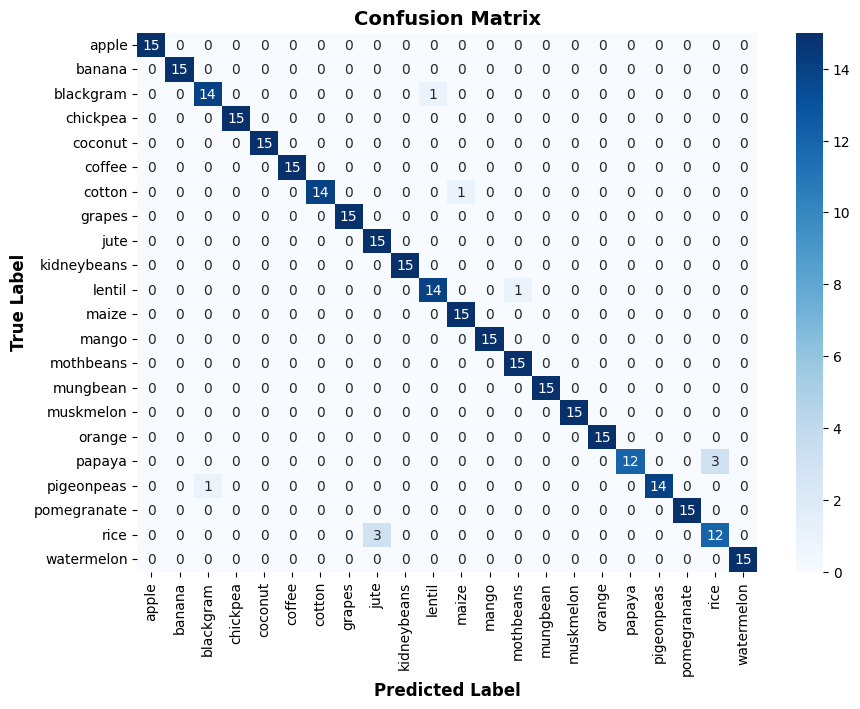

In [49]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)
# print(cm)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')

In [ ]:
import joblib
from pathlib import Path

model_obj = globals().get("model")
if model_obj is None:
    for name in ["best_model", "clf", "log_reg", "lr_model"]:
        if name in globals():
            model_obj = globals()[name]
            break

if model_obj is None:
    raise ValueError("No trained model variable found in notebook globals.")

output_path = Path("../../models/logistic_regression.pkl")
output_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model_obj, output_path)
print(f"Saved model to: {output_path.resolve()}")